<a href="https://colab.research.google.com/github/ximeniki/Crop-disease-and-pest-detection-AI/blob/main/PlantVillage_Q1098267.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#errasing previous unziped data
!rm -rf /content/dataset
!rm -rf /content/archive.zip
!rm -rf /content/leaf.zip
!rm -rf /content/__MACOSX

In [ ]:
#install to access drive files + google auth.
!pip install -q pydrive2

import os
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive

from google.colab import auth
from oauth2client.client import GoogleCredentials
auth.authenticate_user()

#drive conexion configuration
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

file_list = drive.ListFile({'q': "title = 'archive.zip'"}).GetList()
file_id = file_list[0]['id']
f = drive.CreateFile({'id':file_id})
f.GetContentFile('archive.zip')

# unzip file
!unzip -q 'archive.zip' -d '/content/dataset'

#data is divided in train and val folders, printing zip content to know which level we are working on
data_dir = '/content/dataset'
print(f"Zip content: {os.listdir(data_dir)}")

Zip content: ['PlantVillage']


In [ ]:
#now let us see what is inside plant village folder
import os
path = '/content/dataset/PlantVillage'
print(f"Plant Village content: {os.listdir(path)}")

Plant Village content: ['val', 'train']


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, GlobalAveragePooling2D,
                                     Dense, Dropout, SeparableConv2D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#drone architecture
def dron_model(num_clases):
    model = Sequential([
        #standar convolutions
        Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        #separable layers
        SeparableConv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        SeparableConv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        #parameter reduction
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5), #robustness against noise
        Dense(num_clases, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

train_dir = '/content/dataset/PlantVillage/train'
val_dir = '/content/dataset/PlantVillage/val'

#file validation
if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"Error: training directory not found {train_dir}")

#data augmentation strategy
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.5, 1.5]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_dataset = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

num_clases = train_dataset.num_classes
model = dron_model(num_clases)
print(f"\nTotal of {num_clases} classes.")
model.summary()

Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Total of 38 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 109, 109, 64)   │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 52, 52, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,502 (134.77 KB)

 Trainable params: 34,054 (133.02 KB)

 Non-trainable params: 448 (1.75 KB)

Data augmentation image examples

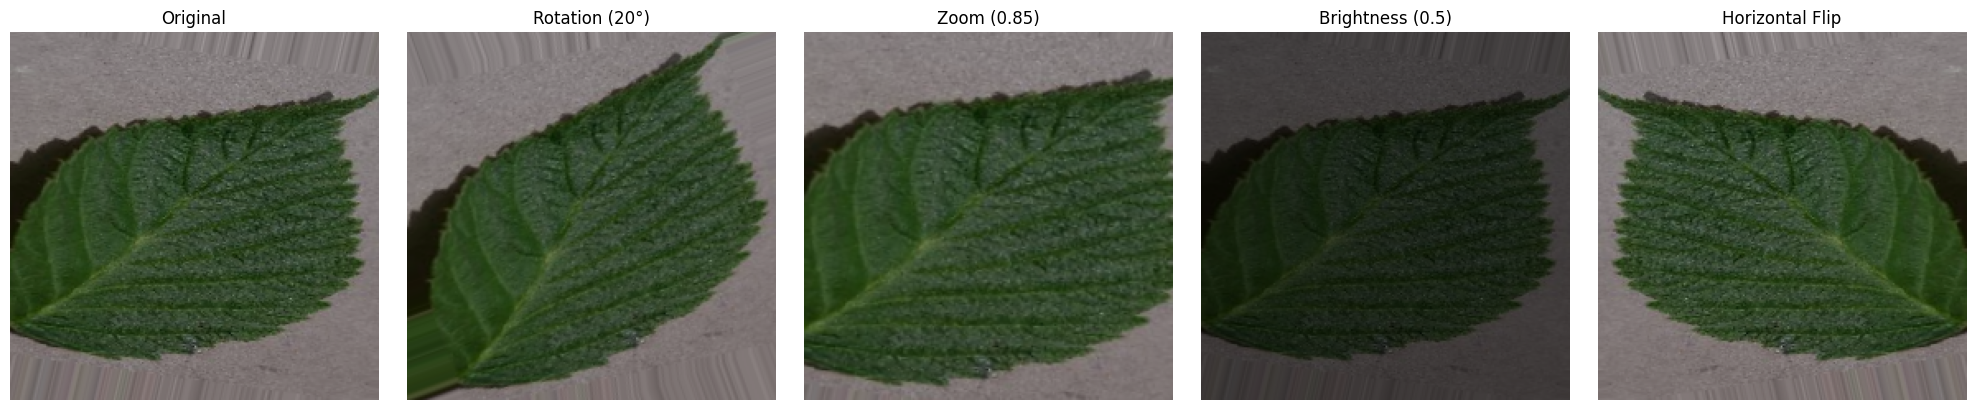

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_dataset)

idx = np.random.randint(0, len(images))
sample_img = images[idx]

titles = ["Original", "Rotation (20°)", "Zoom (0.85)", "Brightness (0.5)", "Horizontal Flip"]
plt.figure(figsize=(20, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    if i == 0:
        display_img = sample_img
    elif i == 1:
        display_img = train_datagen.apply_transform(sample_img, {'theta': 20})
    elif i == 2:
        display_img = train_datagen.apply_transform(sample_img, {'zx': 0.85, 'zy': 0.85})
    elif i == 3:
        display_img = sample_img * 0.5
    elif i == 4:
        display_img = train_datagen.apply_transform(sample_img, {'flip_horizontal': True})

    display_img = np.clip(display_img, 0, 1).astype('float32')
    plt.imshow(display_img)
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

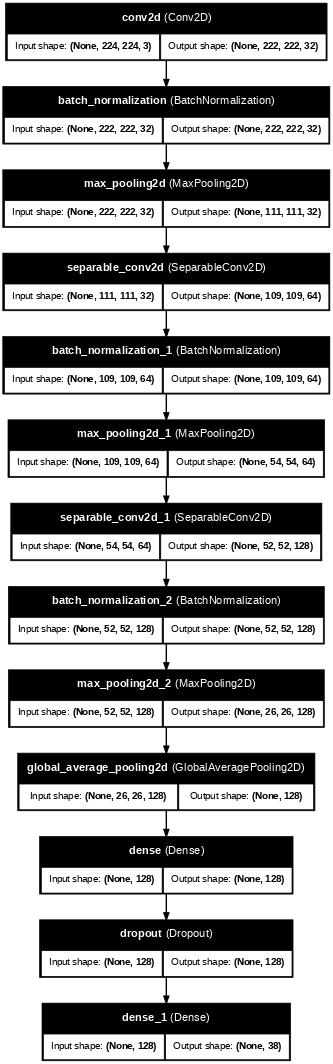

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True, dpi=50)

In [ ]:
#ephocs definition if we want a specific number
#EPOCHS = 30

#rint(f"Training for {EPOCHS} ephocs...")

#creating 'history' to save data and plot afterwards
#history = model.fit(
    #train_dataset,
    #validation_data=validation_dataset,
    #epochs=EPOCHS,
    #verbose=1 #progress bar
#)

#ephocs definition if we want for the model to train until the accuracy does not improve
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    #if the loss dont go lower after 3 epochs, it will reduce the learning rate
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1),
    #if the model dont improve after 7 epochs, it will stop the training to save time
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    #automatically saving the last "better" model
    ModelCheckpoint('best_dron_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

#epochs can change (10, 30, 50, 100)
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    callbacks=callbacks
)
print("\nTraining completed")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.2112 - loss: 3.0635
Epoch 1: val_loss improved from inf to 1.98121, saving model to best_dron_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 601s 429ms/step - accuracy: 0.2113 - loss: 3.0632 - val_accuracy: 0.4350 - val_loss: 1.9812 - learning_rate: 1.0000e-04
Epoch 2/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.4449 - loss: 2.0256
Epoch 2: val_loss improved from 1.98121 to 1.74756, saving model to best_dron_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 558s 411ms/step - accuracy: 0.4449 - loss: 2.0255 - val_accuracy: 0.4981 - val_loss: 1.7476 - learning_rate: 1.0000e-04
Epoch 3/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.5178 - loss: 1.7011
Epoch 3: val_loss improved from 1.74756 to 1.43621, saving model to best_dron_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 567s 417ms/step - accuracy: 0.5178 - loss: 1.7010 - val_accuracy: 0.5742 - val_loss: 1.4362 - learning_rate: 1.0000e-04
Epoch 4/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.5655 - loss: 1.5072
Epoch 4: val_loss improved from 1.43621 to 1.30129, saving model to best_dron_model.h5


...

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 563s 414ms/step - accuracy: 0.6065 - loss: 1.3579 - val_accuracy: 0.6266 - val_loss: 1.2344 - learning_rate: 1.0000e-04
Epoch 6/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.6374 - loss: 1.2252
Epoch 6: val_loss did not improve from 1.23439
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 564s 415ms/step - accuracy: 0.6375 - loss: 1.2252 - val_accuracy: 0.5994 - val_loss: 1.3407 - learning_rate: 1.0000e-04
Epoch 7/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6645 - loss: 1.1320
Epoch 7: val_loss improved from 1.23439 to 1.13332, saving model to best_dron_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 568s 418ms/step - accuracy: 0.6645 - loss: 1.1320 - val_accuracy: 0.6587 - val_loss: 1.1333 - learning_rate: 1.0000e-04
Epoch 8/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.6830 - loss: 1.0475
Epoch 8: val_loss improved from 1.13332 to 0.95846, saving model to best_dron_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 563s 414ms/step - accuracy: 0.6830 - loss: 1.0475 - val_accuracy: 0.7037 - val_loss: 0.9585 - learning_rate: 1.0000e-04
Epoch 9/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.7141 - loss: 0.9682
Epoch 9: val_loss did not improve from 0.95846
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 566s 417ms/step - accuracy: 0.7141 - loss: 0.9682 - val_accuracy: 0.6619 - val_loss: 1.1442 - learning_rate: 1.0000e-04
Epoch 10/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.7252 - loss: 0.9097
Epoch 10: val_loss did not improve from 0.95846
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 562s 414ms/step - accuracy: 0.7252 - loss: 0.9097 - val_accuracy: 0.6867 - val_loss: 1.0300 - learning_rate: 1.0000e-04
Epoch 11/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.7387 - loss: 0.8624
Epoch 11: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 11: val_loss did not improve from 0.95846
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 579s 426ms/step - accu

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 565s 416ms/step - accuracy: 0.7545 - loss: 0.8116 - val_accuracy: 0.7212 - val_loss: 0.9126 - learning_rate: 2.0000e-05
Epoch 13/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.7522 - loss: 0.8027
Epoch 13: val_loss improved from 0.91256 to 0.83967, saving model to best_dron_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 559s 412ms/step - accuracy: 0.7522 - loss: 0.8027 - val_accuracy: 0.7394 - val_loss: 0.8397 - learning_rate: 2.0000e-05
Epoch 14/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.7610 - loss: 0.7872
Epoch 14: val_loss did not improve from 0.83967
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 556s 410ms/step - accuracy: 0.7611 - loss: 0.7872 - val_accuracy: 0.7124 - val_loss: 0.9639 - learning_rate: 2.0000e-05
Epoch 15/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7601 - loss: 0.7877
Epoch 15: val_loss did not improve from 0.83967
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 567s 418ms/step - accuracy: 0.7601 - loss: 0.7877 - val_accuracy: 0.7257 - val_loss: 0.9015 - learning_rate: 2.0000e-05
Epoch 16/50
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.7667 - loss: 0.7714
Epoch 16: ReduceLROnPlateau reducing learning rate to 1e-05.

Epoch 16: val_loss did not improve from 0.83967
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 560s 412ms/step - accuracy: 0.7667 - 

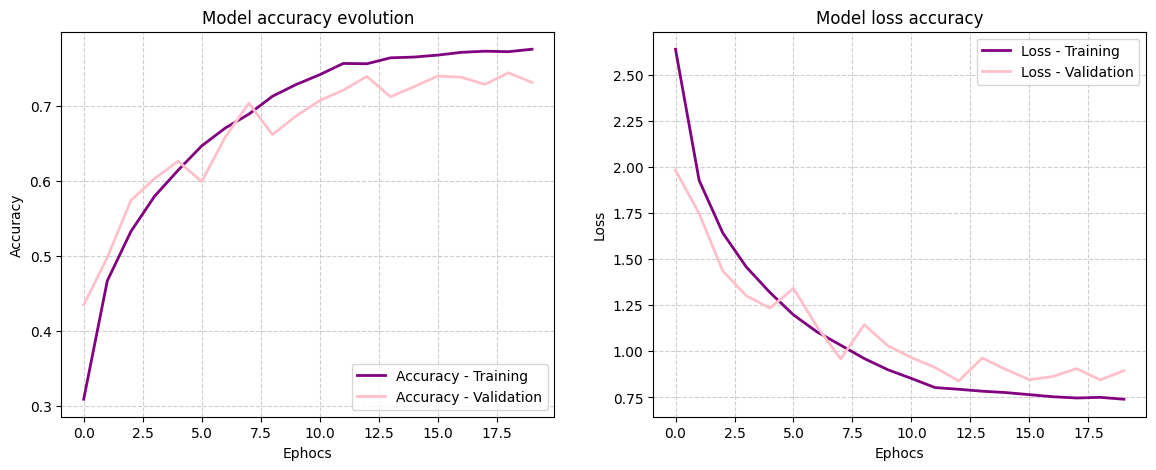

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

#accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuracy - Training', color='purple', lw=2)
plt.plot(epochs_range, val_acc, label='Accuracy - Validation', color='pink', lw=2)
plt.title('Model accuracy evolution')
plt.xlabel('Ephocs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

#loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss - Training', color='purple', lw=2)
plt.plot(epochs_range, val_loss, label='Loss - Validation', color='pink', lw=2)
plt.title('Model loss accuracy')
plt.xlabel('Ephocs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step


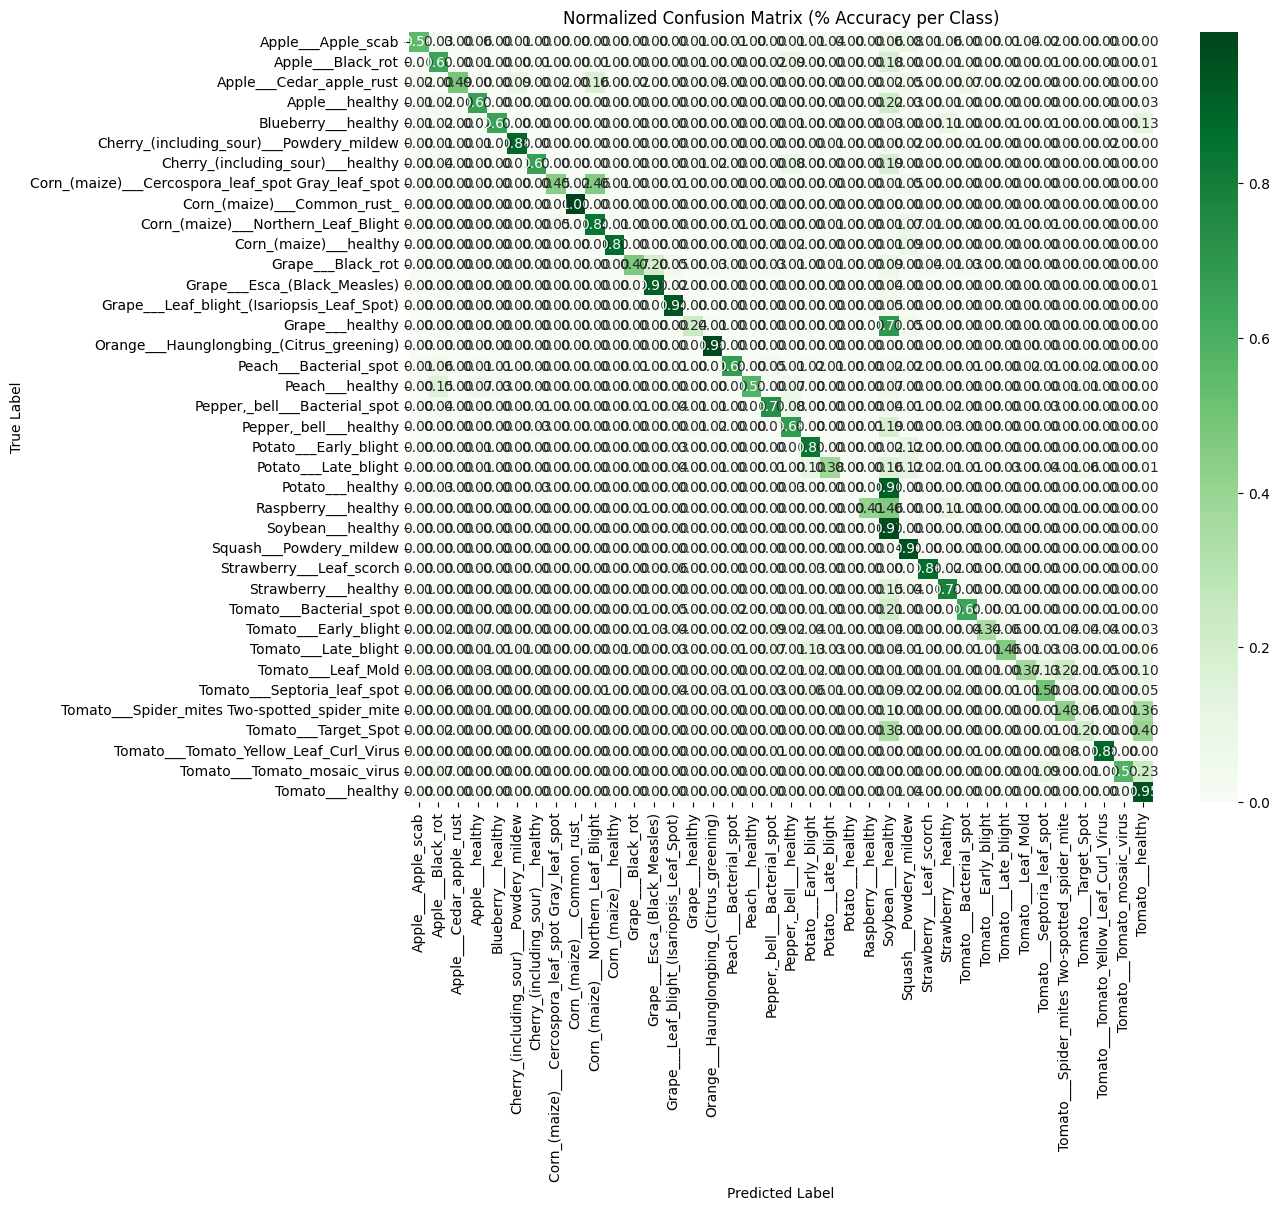

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions and labels
class_names = list(validation_dataset.class_indices.keys())
validation_dataset.reset()
predictions = model.predict(validation_dataset, verbose=1)
true_labels = validation_dataset.classes
predicted_labels = np.argmax(predictions, axis=1)

# 2. Generate the Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

# 3. Normalize the matrix (Divide each row by the sum of that row)
# We add a tiny epsilon (1e-9) to avoid division by zero if a class is empty
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized,
            annot=True,
            cmap='Greens',
            fmt='.2f', # Show 2 decimal places (e.g., 0.95 for 95%)
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Normalized Confusion Matrix (% Accuracy per Class)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

f1 = f1_score(true_labels, predicted_labels, average='weighted')
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')

#ROC-AUC Score
if len(np.unique(true_labels)) > 2:
    #multi-class AUC
    true_labels_one_hot = np.eye(len(np.unique(true_labels)))[true_labels]
    roc_auc = roc_auc_score(true_labels_one_hot, predictions, multi_class='ovr')
else:
    #binary AUC
    roc_auc = roc_auc_score(true_labels, predictions[:,1])

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

F1 Score: 0.7317
Precision: 0.7735
Recall: 0.7394
ROC-AUC Score: 0.9860


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
